# DistilBERT for Disaster Tweet Detection

Previous experiments showed that TF-IDF models rely heavily on individual keywords and struggle with contextual understanding.

Examples such as:

- "my heart exploded"
- "farts that creates an earthquake"

demonstrate the limitations of bag-of-words representations.

To address these issues, a transformer-based model (DistilBERT) is fine-tuned on the disaster tweet classification task.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    train_data["text"],
    train_data["target"],
    test_size=0.2,
    random_state=42,
    stratify=train_data["target"]
)

In [5]:
from datasets import Dataset

train_df = pd.DataFrame({
    "text": X_train,
    "label": y_train
})

val_df = pd.DataFrame({
    "text": X_val,
    "label": y_val
})

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

The same train-validation split used in the TF-IDF experiments is retained to ensure a fair comparison.

In [6]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [46]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [47]:
train_dataset = train_dataset.map(
    tokenize,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/6090 [00:00<?, ? examples/s]

Map:   0%|          | 0/1523 [00:00<?, ? examples/s]

Tweets are tokenized using the DistilBERT tokenizer and truncated to a maximum sequence length of 128 tokens.

In [48]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [49]:
from sklearn.metrics import f1_score
import numpy as np

def compute_metrics(eval_pred):

    logits = eval_pred.predictions
    labels = eval_pred.label_ids

    preds = np.argmax(
        logits,
        axis=1
    )

    return {
        "f1": f1_score(labels, preds)
    }

In [57]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",

    eval_strategy="epoch",
    save_strategy="epoch",

    per_device_train_batch_size=64,
    per_device_eval_batch_size=32,

    num_train_epochs=5,
    learning_rate=2e-5,

    weight_decay=0.01,

    warmup_steps=1000,

    lr_scheduler_type="linear",

    load_best_model_at_end=True,

    metric_for_best_model="f1",
    greater_is_better=True
)

In [58]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [59]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1
1,No log,0.387098,0.820064
2,No log,0.423065,0.806061
3,No log,0.413278,0.801843
4,No log,0.426651,0.803667
5,No log,0.474282,0.795489


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=480, training_loss=0.26483141581217445, metrics={'train_runtime': 491.1683, 'train_samples_per_second': 61.995, 'train_steps_per_second': 0.977, 'total_flos': 1008408072268800.0, 'train_loss': 0.26483141581217445, 'epoch': 5.0})

In [60]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,F1
No log,0.387098,5,0.820064


{'eval_loss': 0.38709843158721924, 'eval_f1': 0.8200636942675159}

In [61]:
predictions = trainer.predict(
    val_dataset
)

In [64]:
from sklearn.metrics import confusion_matrix

bert_preds = np.argmax(
    predictions.predictions,
    axis=1
)

cm = confusion_matrix(
    y_val,
    bert_preds
)

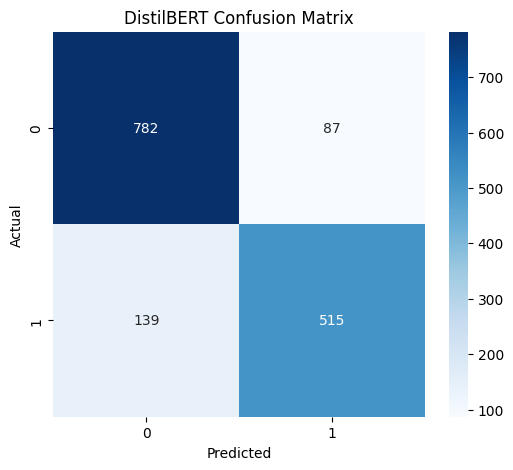

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "DistilBERT Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [69]:
bert_results = pd.DataFrame({
    "text": X_val.values,
    "target": y_val.values,
    "prediction": bert_preds
})

In [70]:
bert_fp = bert_results[
    (bert_results.target == 0)
    &
    (bert_results.prediction == 1)
]

In [71]:
bert_fn = bert_results[
    (bert_results.target == 1)
    &
    (bert_results.prediction == 0)
]

In [72]:
print(f'False positive: {bert_fp}')

False positive:                                                    text  target  prediction
0     @TheEconomist Step one: get that mass murderer...       0           1
11    MEGALPOLIS Area Petting Party Shiver \nFear In...       0           1
14    if firefighters acted like cops they'd drive a...       0           1
34               @TroySlaby22 slicker than an oil spill       0           1
43    Has An Ancient Nuclear Reactor Been Discovered...       0           1
...                                                 ...     ...         ...
1427  @CaraJDeIevingnc the bomb impact ratio hit bey...       0           1
1462  Uber reduces drunk driving fatalities says ind...       0           1
1483  Growth dries up for BHP Billiton as oil price ...       0           1
1498  http://t.co/GKYe6gjTk5 Had a #personalinjury a...       0           1
1516  .@runjewels recently met with the @BBC to disc...       0           1

[87 rows x 3 columns]


In [73]:
print(f'False negative: {bert_fn}')

False negative:                                                    text  target  prediction
5     Hollywood Movie About Trapped Miners Released ...       1           0
7         I can't drown my demons they know how to swim       1           0
16    'It looks like a mudslide' poor thing! ?? #gre...       1           0
27    I agree with certain cultural appropriation th...       1           0
29    The Dress Memes Have Officially Exploded On Th...       1           0
...                                                 ...     ...         ...
1473  Inbounds/ Out of Bounds:\n\nWhile many picked ...       1           0
1474  @fewmoretweets all lives matter. Just not a fa...       1           0
1491  #Glaucoma occurs when fluid builds up pressure...       1           0
1500  Whirlwind Medusa Audio Snake: 16 microphone in...       1           0
1520  b/c it costs less to have sick people using em...       1           0

[139 rows x 3 columns]


DistilBERT improved the validation F1 score by approximately 5 percentage points compared to the strongest TF-IDF baseline.

This improvement suggests that contextual language representations are beneficial for disaster tweet classification.

In [75]:
trainer.save_model(
    "./models/distilbert"
)

tokenizer.save_pretrained(
    "./models/distilbert"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./models/distilbert/tokenizer_config.json',
 './models/distilbert/tokenizer.json')

## Conclusions

Key findings:

- Logistic Regression provides a strong and interpretable baseline.
- Error analysis revealed that TF-IDF models struggle with contextual understanding.
- DistilBERT achieved the best overall performance (F1 ≈ 0.823).
- Transformer-based representations reduce keyword dependency and improve robustness to figurative language.

Future work may include:

- RoBERTa or DeBERTa fine-tuning
- Hyperparameter optimization
- Cross-validation
- Threshold optimization